# CDT Morris CRISPRi: Prediction Analysis (Stage 1.5)

## Overview
- **Goal**: Evaluate prediction accuracy and cell-level heterogeneity
- **Model**: CDT-II Stage 1.5 (DNA + RNA, 2,361 genes including GFI1B)
- **Data**: Morris STINGseq TSS + SNP perturbations (cell-level)

## Stage 1.5 Changes from Stage 1
- Gene count: 2,360 → **2,361** (GFI1B added at index 2360)
- Training: 500+ epochs, patience=30, checkpoint resume
- GFI1B self-knockdown analysis now available

## Contents
1. Setup & Data Loading
2. Model Definition & Loading
3. Overall Prediction Performance
4. Per-Gene Validation Analysis
5. Cell-Level Heterogeneity Analysis
6. TSS vs SNP Effect Size Comparison
7. Per-Gene Effect Profiles
8. Summary Statistics

## 1. Setup

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Check GPU
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4


In [ ]:
!pip install h5py tqdm scipy seaborn -q

import os
import h5py
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from tqdm import tqdm
from datetime import datetime
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from typing import Optional, Dict, List

class NumpyEncoder(json.JSONEncoder):
    """JSON encoder that handles numpy types."""
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, np.bool_):
            return bool(obj)
        return super().default(obj)

print("All imports successful!")

All imports successful!


## 2. Paths Configuration

In [ ]:
# Google Drive paths
DRIVE_BASE = Path("/content/drive/MyDrive/cdt_data")
MODEL_BASE = Path("/content/drive/MyDrive/cdt_outputs/morris_crispri_stage1_5")
OUTPUT_BASE = Path("/content/drive/MyDrive/cdt_outputs/morris_analysis_stage1_5")
OUTPUT_BASE.mkdir(parents=True, exist_ok=True)

# Cell-level effects (Stage 1.5: 2361 genes)
TSS_EFFECTS_PATH = DRIVE_BASE / "morris_celllevel_effects_2361.h5"
SNP_EFFECTS_PATH = DRIVE_BASE / "morris_snp_celllevel_effects_2361.h5"

# Enformer embeddings (unchanged)
TSS_ENFORMER_PATH = DRIVE_BASE / "morris_28genes_enformer.h5"
SNP_ENFORMER_PATH = DRIVE_BASE / "morris_snp_enformer.h5"

# Gene list (load from cell-level H5 which has 2361 genes)
GENE_LIST_PATH = DRIVE_BASE / "k562_gene_embeddings_aligned.h5"

# Model (Stage 1.5)
MODEL_PATH = MODEL_BASE / "cdt_morris_celllevel_best.pt"

# Check files
print("Checking files...")
for name, path in [
    ("TSS cell-level effects (2361)", TSS_EFFECTS_PATH),
    ("SNP cell-level effects (2361)", SNP_EFFECTS_PATH),
    ("TSS Enformer embeddings", TSS_ENFORMER_PATH),
    ("SNP Enformer embeddings", SNP_ENFORMER_PATH),
    ("Gene list (2360 base)", GENE_LIST_PATH),
    ("Trained model (Stage 1.5)", MODEL_PATH),
]:
    status = "OK" if path.exists() else "NOT FOUND"
    print(f"  [{status}] {name}: {path}")

Checking files...
  [OK] TSS cell-level effects (2361): /content/drive/MyDrive/cdt_data/morris_celllevel_effects_2361.h5
  [OK] SNP cell-level effects (2361): /content/drive/MyDrive/cdt_data/morris_snp_celllevel_effects_2361.h5
  [OK] TSS Enformer embeddings: /content/drive/MyDrive/cdt_data/morris_28genes_enformer.h5
  [OK] SNP Enformer embeddings: /content/drive/MyDrive/cdt_data/morris_snp_enformer.h5
  [OK] Gene list (2360 base): /content/drive/MyDrive/cdt_data/k562_gene_embeddings_aligned.h5
  [OK] Trained model (Stage 1.5): /content/drive/MyDrive/cdt_outputs/morris_crispri_stage1_5/cdt_morris_celllevel_best.pt


## 3. Load Data

In [ ]:
# Load CDT gene list (Stage 1.5: 2361 genes = 2360 base + GFI1B)
print("Loading CDT gene list...")

# Load base 2360 genes from RNA embeddings, then append GFI1B
with h5py.File(GENE_LIST_PATH, 'r') as f:
    cdt_genes = [g.decode() if isinstance(g, bytes) else g for g in f['gene_names'][:]]
if 'GFI1B' not in cdt_genes:
    cdt_genes.append('GFI1B')
    print("  GFI1B appended to gene list.")
N_GENES = len(cdt_genes)
gene_to_idx = {g: i for i, g in enumerate(cdt_genes)}
print(f"  CDT genes: {N_GENES}")
print(f"  GFI1B index: {gene_to_idx.get('GFI1B', 'NOT FOUND')}")
assert N_GENES == 2361, f"Expected 2361 genes, got {N_GENES}"
assert 'GFI1B' in gene_to_idx, "GFI1B must be in gene list"

Loading CDT gene list...
  GFI1B appended to gene list.
  CDT genes: 2361
  GFI1B index: 2360


In [ ]:
# Load TSS cell-level effects
print("\nLoading TSS cell-level effects...")
with h5py.File(TSS_EFFECTS_PATH, 'r') as f:
    tss_log2fc = f['log2fc'][:]            # [n_cells, 2360]
    tss_cell_expr = f['cell_expr'][:]      # [n_cells, 2360]
    tss_target_gene_idx = f['target_gene_idx'][:]  # [n_cells]
    tss_target_gene_names = [g.decode() if isinstance(g, bytes) else g
                             for g in f['target_gene_names'][:]]
    tss_val_genes = [g.decode() if isinstance(g, bytes) else g
                     for g in f['val_genes'][:]]
    tss_train_genes = [g.decode() if isinstance(g, bytes) else g
                       for g in f['train_genes'][:]]
    tss_n_cells_per_gene = f['n_cells_per_gene'][:]
    ntc_mean_expr = f['ntc_mean_expr'][:]  # [2360] log1p CPM

print(f"  Cells: {tss_log2fc.shape[0]}")
print(f"  Target genes: {len(tss_target_gene_names)}")
print(f"  Val genes: {tss_val_genes}")
print(f"  Train genes: {len(tss_train_genes)}")


Loading TSS cell-level effects...
  Cells: 8250
  Target genes: 27
  Val genes: ['CD44', 'CD52', 'GFI1B', 'TFRC', 'TNFSF9']
  Train genes: 22


In [ ]:
# Load SNP cell-level effects
print("\nLoading SNP cell-level effects...")
if SNP_EFFECTS_PATH.exists():
    with h5py.File(SNP_EFFECTS_PATH, 'r') as f:
        snp_log2fc = f['log2fc'][:]           # [n_cells, 2360]
        snp_cell_expr = f['cell_expr'][:]     # [n_cells, 2360]
        snp_perturbation_idx = f['perturbation_idx'][:]  # [n_cells]
        snp_loci_names = [g.decode() if isinstance(g, bytes) else g
                          for g in f['snp_loci_names'][:]]
        snp_ids = f['snp_ids'][:]
        snp_n_cells_per_locus = f['n_cells_per_locus'][:]
    print(f"  SNP cells: {snp_log2fc.shape[0]}")
    print(f"  SNP loci: {len(snp_loci_names)}")
    HAS_SNP = True
else:
    print("  SNP effects file not found, skipping SNP analysis")
    HAS_SNP = False


Loading SNP cell-level effects...
  SNP cells: 7407
  SNP loci: 420


In [ ]:
# Load Enformer embeddings
print("\nLoading Enformer embeddings...")
with h5py.File(TSS_ENFORMER_PATH, 'r') as f:
    tss_enformer_emb = f['embeddings'][:]  # [n_genes, 896, 3072]
    tss_enformer_genes = [g.decode() if isinstance(g, bytes) else g
                          for g in f['gene_names'][:]]
print(f"  TSS Enformer shape: {tss_enformer_emb.shape}")
print(f"  TSS Enformer genes: {tss_enformer_genes}")

# Build mapping: target gene name -> Enformer index
tss_gene_to_enformer = {gene: i for i, gene in enumerate(tss_enformer_genes)}

if HAS_SNP and SNP_ENFORMER_PATH.exists():
    with h5py.File(SNP_ENFORMER_PATH, 'r') as f:
        snp_enformer_emb = f['embeddings'][:]  # [n_loci, 896, 3072]
        snp_enformer_ids = f["snp_ids"][:]
    print(f"  SNP Enformer shape: {snp_enformer_emb.shape}")
    print(f"  SNP Enformer loci: {len(snp_enformer_ids)}")
else:
    print("  SNP Enformer not loaded")


Loading Enformer embeddings...
  TSS Enformer shape: (28, 896, 3072)
  TSS Enformer genes: ['CD52', 'CD58', 'FCGR2A', 'CD55', 'ITGB1', 'ENTPD1', 'CD81', 'CD44', 'CD82', 'SLC3A2', 'KLRG1', 'CD69', 'KLRD1', 'TNFSF13B', 'LGALS3', 'B2M', 'IL21R', 'CD19', 'ITGAE', 'TNFSF9', 'ICAM1', 'NECTIN2', 'EPCAM', 'CD40', 'TFRC', 'CD83', 'MSR1', 'GFI1B']
  SNP Enformer shape: (493, 896, 3072)
  SNP Enformer loci: 493


## 4. Model Definition

In [ ]:
@dataclass
class CDTCRISPRiConfig:
    """Config for CRISPRi effect prediction"""
    dna_dim: int = 3072
    dna_seq_len: int = 896
    n_genes: int = 2361  # Stage 1.5: 2360 + GFI1B
    hidden_dim: int = 512
    nhead: int = 8
    dropout: float = 0.3
    dna_self_attn_layers: int = 2
    rna_self_attn_layers: int = 1


class RawExpressionEncoder(nn.Module):
    """Raw expression -> hidden_dim embeddings"""
    def __init__(self, n_genes: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        self.n_genes = n_genes
        self.hidden_dim = hidden_dim
        self.gene_embedding = nn.Embedding(n_genes, hidden_dim)
        self.expr_projector = nn.Sequential(
            nn.Linear(1, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(dropout)
        )
        self.combine = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim), nn.LayerNorm(hidden_dim), nn.Dropout(dropout)
        )

    def forward(self, expression: torch.Tensor) -> torch.Tensor:
        batch_size = expression.size(0)
        device = expression.device
        gene_ids = torch.arange(self.n_genes, device=device)
        gene_emb = self.gene_embedding(gene_ids).unsqueeze(0).expand(batch_size, -1, -1)
        expr_emb = self.expr_projector(expression.unsqueeze(-1))
        combined = torch.cat([gene_emb, expr_emb], dim=-1)
        return self.combine(combined)


class SequenceProjector(nn.Module):
    def __init__(self, input_dim: int, output_dim: int, dropout: float = 0.1):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        self.norm = nn.LayerNorm(output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(self.norm(self.linear(x)))


class FlashSelfAttentionBlock(nn.Module):
    def __init__(self, d_model: int, nhead: int = 8, dropout: float = 0.1):
        super().__init__()
        self.d_model = d_model
        self.nhead = nhead
        self.head_dim = d_model // nhead
        self.dropout_p = dropout
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model), nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor):
        batch_size, seq_len, _ = x.shape
        Q = self.q_proj(x).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)
        K = self.k_proj(x).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)
        V = self.v_proj(x).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)
        attn_out = F.scaled_dot_product_attention(Q, K, V, dropout_p=self.dropout_p if self.training else 0.0)
        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        attn_out = self.out_proj(attn_out)
        x = self.norm1(x + self.dropout(attn_out))
        x = self.norm2(x + self.ffn(x))
        return x


class FlashCrossAttentionBlock(nn.Module):
    def __init__(self, d_model: int, nhead: int = 8, dropout: float = 0.1):
        super().__init__()
        self.d_model = d_model
        self.nhead = nhead
        self.head_dim = d_model // nhead
        self.dropout_p = dropout
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model), nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query: torch.Tensor, key_value: torch.Tensor):
        batch_size, query_len, _ = query.shape
        key_len = key_value.shape[1]
        Q = self.q_proj(query).view(batch_size, query_len, self.nhead, self.head_dim).transpose(1, 2)
        K = self.k_proj(key_value).view(batch_size, key_len, self.nhead, self.head_dim).transpose(1, 2)
        V = self.v_proj(key_value).view(batch_size, key_len, self.nhead, self.head_dim).transpose(1, 2)
        attn_out = F.scaled_dot_product_attention(Q, K, V, dropout_p=self.dropout_p if self.training else 0.0)
        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, query_len, self.d_model)
        attn_out = self.out_proj(attn_out)
        x = self.norm1(query + self.dropout(attn_out))
        x = self.norm2(x + self.ffn(x))
        return x


class VirtualCellEmbedderDNARNA(nn.Module):
    """VCE: DNA + RNA only (2 modalities)"""
    def __init__(self, d_model: int, dropout: float = 0.1):
        super().__init__()
        self.d_model = d_model
        self.nhead = 4
        self.head_dim = d_model // self.nhead
        self.dna_query = nn.Parameter(torch.randn(1, 1, d_model))
        self.rna_query = nn.Parameter(torch.randn(1, 1, d_model))
        self.dna_q_proj = nn.Linear(d_model, d_model)
        self.dna_k_proj = nn.Linear(d_model, d_model)
        self.dna_v_proj = nn.Linear(d_model, d_model)
        self.dna_out_proj = nn.Linear(d_model, d_model)
        self.rna_q_proj = nn.Linear(d_model, d_model)
        self.rna_k_proj = nn.Linear(d_model, d_model)
        self.rna_v_proj = nn.Linear(d_model, d_model)
        self.rna_out_proj = nn.Linear(d_model, d_model)
        self.fusion = nn.Sequential(
            nn.Linear(d_model * 2, d_model * 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model), nn.LayerNorm(d_model)
        )

    def _attention_pool(self, query, key_value, q_proj, k_proj, v_proj, out_proj):
        batch_size = key_value.size(0)
        seq_len = key_value.size(1)
        query = query.expand(batch_size, -1, -1)
        Q = q_proj(query).view(batch_size, 1, self.nhead, self.head_dim).transpose(1, 2)
        K = k_proj(key_value).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)
        V = v_proj(key_value).view(batch_size, seq_len, self.nhead, self.head_dim).transpose(1, 2)
        attn_out = F.scaled_dot_product_attention(Q, K, V)
        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, 1, self.d_model)
        return out_proj(attn_out).squeeze(1)

    def forward(self, dna_encoded, rna_encoded):
        dna_pooled = self._attention_pool(
            self.dna_query, dna_encoded,
            self.dna_q_proj, self.dna_k_proj, self.dna_v_proj, self.dna_out_proj
        )
        rna_pooled = self._attention_pool(
            self.rna_query, rna_encoded,
            self.rna_q_proj, self.rna_k_proj, self.rna_v_proj, self.rna_out_proj
        )
        concat = torch.cat([dna_pooled, rna_pooled], dim=-1)
        return self.fusion(concat)


class CDTCRISPRiModel(nn.Module):
    """
    CDT Model for CRISPRi Effect Prediction (Stage 1.5: 2361 genes)
    Input: dna_emb [batch, 896, 3072], rna_expr [batch, 2361]
    Output: effect [batch, 2361] log2 fold change
    """
    def __init__(self, config: Optional[CDTCRISPRiConfig] = None):
        super().__init__()
        if config is None:
            config = CDTCRISPRiConfig()
        self.config = config
        self.dna_projector = SequenceProjector(config.dna_dim, config.hidden_dim, config.dropout)
        self.dna_self_attn_layers = nn.ModuleList([
            FlashSelfAttentionBlock(config.hidden_dim, config.nhead, config.dropout)
            for _ in range(config.dna_self_attn_layers)
        ])
        self.rna_encoder = RawExpressionEncoder(config.n_genes, config.hidden_dim, config.dropout)
        self.rna_self_attn_layers = nn.ModuleList([
            FlashSelfAttentionBlock(config.hidden_dim, config.nhead, config.dropout)
            for _ in range(config.rna_self_attn_layers)
        ])
        self.dna_to_rna = FlashCrossAttentionBlock(config.hidden_dim, config.nhead, config.dropout)
        self.vce = VirtualCellEmbedderDNARNA(config.hidden_dim, config.dropout)
        self.task_layer = nn.Sequential(
            nn.Linear(config.hidden_dim, config.hidden_dim), nn.GELU(), nn.Dropout(config.dropout),
            nn.Linear(config.hidden_dim, config.n_genes)
        )

    def forward(self, dna_emb, rna_expr):
        dna = self.dna_projector(dna_emb)
        rna = self.rna_encoder(rna_expr)
        for layer in self.dna_self_attn_layers:
            dna = layer(dna)
        for layer in self.rna_self_attn_layers:
            rna = layer(rna)
        rna = self.dna_to_rna(query=rna, key_value=dna)
        cell_embedding = self.vce(dna, rna)
        effect = self.task_layer(cell_embedding)
        return effect

    def get_num_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

print("Model classes defined!")

Model classes defined!


## 5. Load Model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

config = CDTCRISPRiConfig()
model = CDTCRISPRiModel(config).to(device)

state_dict = torch.load(MODEL_PATH, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model.eval()

print(f"Model loaded from: {MODEL_PATH}")
print(f"Parameters: {model.get_num_params():,}")

Device: cuda
Model loaded from: /content/drive/MyDrive/cdt_outputs/morris_crispri_stage1_5/cdt_morris_celllevel_best.pt
Parameters: 21,072,185


## 6. Overall Prediction Performance

In [ ]:
# Collect predictions for all validation cells
print("Running inference on validation cells...")

# Build val cell indices
val_gene_set = set(tss_val_genes)
val_gene_indices = {gene: i for i, gene in enumerate(tss_target_gene_names) if gene in val_gene_set}
val_cell_mask = np.array([tss_target_gene_names[idx] in val_gene_set for idx in tss_target_gene_idx])
val_cell_indices = np.where(val_cell_mask)[0]

print(f"  Val genes: {list(val_gene_indices.keys())}")
print(f"  Val cells: {len(val_cell_indices)}")

# Run inference in batches
all_preds = []
all_targets = []
all_gene_labels = []  # which gene each cell was perturbed for

batch_size = 16
with torch.no_grad():
    for start in tqdm(range(0, len(val_cell_indices), batch_size)):
        end = min(start + batch_size, len(val_cell_indices))
        batch_indices = val_cell_indices[start:end]

        # Get DNA embeddings for each cell's perturbation target
        dna_batch = []
        for ci in batch_indices:
            gene_name = tss_target_gene_names[tss_target_gene_idx[ci]]
            enf_idx = tss_gene_to_enformer[gene_name]
            dna_batch.append(tss_enformer_emb[enf_idx])

        dna_tensor = torch.from_numpy(np.stack(dna_batch).astype(np.float32)).to(device)
        rna_tensor = torch.from_numpy(tss_cell_expr[batch_indices].astype(np.float32)).to(device)

        pred = model(dna_tensor, rna_tensor)
        all_preds.append(pred.cpu().numpy())
        all_targets.append(tss_log2fc[batch_indices])

        for ci in batch_indices:
            all_gene_labels.append(tss_target_gene_names[tss_target_gene_idx[ci]])

all_preds = np.concatenate(all_preds, axis=0)  # [n_val_cells, 2360]
all_targets = np.concatenate(all_targets, axis=0)  # [n_val_cells, 2360]
all_gene_labels = np.array(all_gene_labels)

print(f"\nPredictions shape: {all_preds.shape}")
print(f"Targets shape: {all_targets.shape}")

Running inference on validation cells...
  Val genes: ['CD44', 'CD52', 'GFI1B', 'TFRC', 'TNFSF9']
  Val cells: 2037


100%|██████████| 128/128 [00:57<00:00,  2.22it/s]


Predictions shape: (2037, 2361)
Targets shape: (2037, 2361)


In [ ]:
# Overall performance: flatten all cells x all genes
pred_flat = all_preds.flatten()
target_flat = all_targets.flatten()

overall_r, overall_p = pearsonr(pred_flat, target_flat)
overall_rho, _ = spearmanr(pred_flat, target_flat)

print(f"Overall Prediction Performance (all cells x all genes):")
print(f"  Pearson r  = {overall_r:.4f} (p = {overall_p:.2e})")
print(f"  Spearman rho = {overall_rho:.4f}")
print(f"  MSE = {np.mean((pred_flat - target_flat)**2):.6f}")
print(f"  MAE = {np.mean(np.abs(pred_flat - target_flat)):.6f}")

Overall Prediction Performance (all cells x all genes):
  Pearson r  = 0.6373 (p = 0.00e+00)
  Spearman rho = 0.4382
  MSE = 0.059549
  MAE = 0.132703


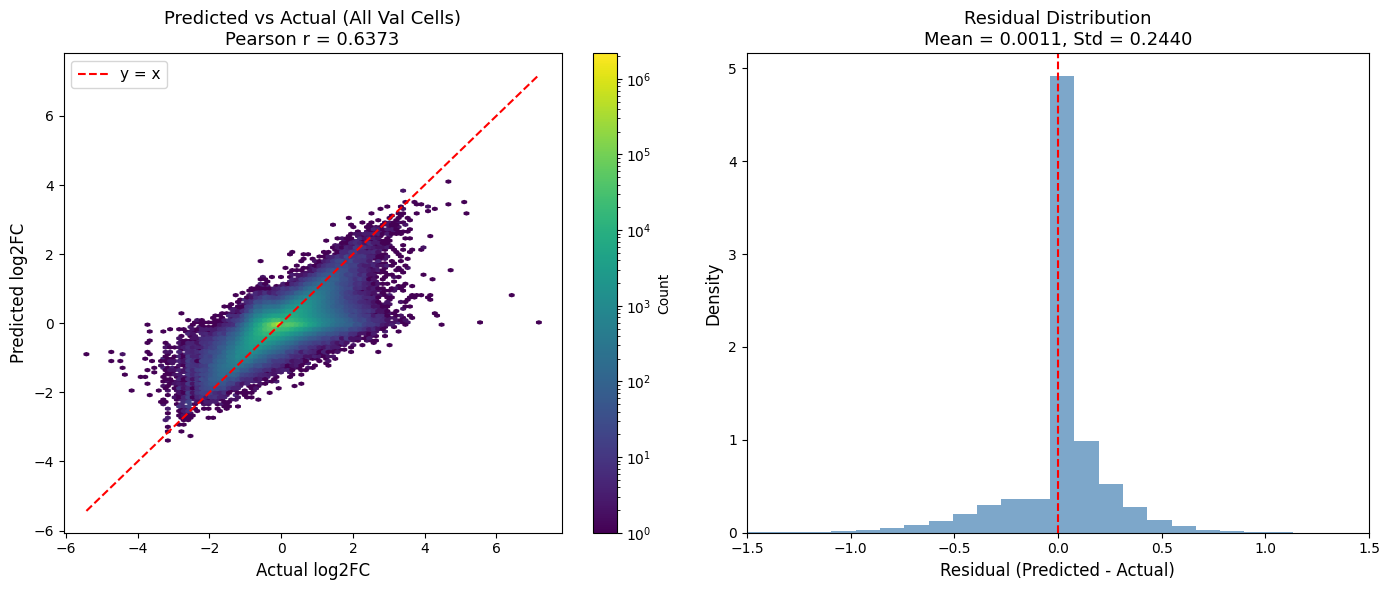

In [ ]:
from matplotlib.colors import LogNorm

# Scatter plot: predicted vs actual (density plot)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Density scatter
ax = axes[0]
hb = ax.hexbin(target_flat, pred_flat, gridsize=100, cmap='viridis', mincnt=1, norm=LogNorm())
ax.plot([target_flat.min(), target_flat.max()], [target_flat.min(), target_flat.max()],
        'r--', linewidth=1.5, label='y = x')
ax.set_xlabel('Actual log2FC', fontsize=12)
ax.set_ylabel('Predicted log2FC', fontsize=12)
ax.set_title(f'Predicted vs Actual (All Val Cells)\nPearson r = {overall_r:.4f}', fontsize=13)
ax.legend(fontsize=11)
plt.colorbar(hb, ax=ax, label='Count')

# Residual distribution
ax = axes[1]
residuals = pred_flat - target_flat
ax.hist(residuals, bins=100, density=True, alpha=0.7, color='steelblue')
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlim(-1.5, 1.5)
ax.set_xlabel('Residual (Predicted - Actual)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Residual Distribution\nMean = {residuals.mean():.4f}, Std = {residuals.std():.4f}', fontsize=13)

plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'prediction_overall.png', dpi=150, bbox_inches='tight')
plt.savefig(OUTPUT_BASE / 'prediction_overall.pdf', bbox_inches='tight')
plt.show()

## 7. Per-Gene Validation Analysis

In [ ]:
# Per-gene analysis for each val gene
print("Per-Gene Validation Analysis")
print("=" * 60)

per_gene_results = {}

for gene in tss_val_genes:
    mask = all_gene_labels == gene
    n_cells = mask.sum()

    gene_preds = all_preds[mask]    # [n_cells, 2360]
    gene_targets = all_targets[mask]  # [n_cells, 2360]

    # r(all cells): flatten all cells x all genes
    r_all, p_all = pearsonr(gene_preds.flatten(), gene_targets.flatten())

    # r(mean): mean across cells, then correlation across genes
    mean_pred = gene_preds.mean(axis=0)  # [2360]
    mean_target = gene_targets.mean(axis=0)  # [2360]
    r_mean, p_mean = pearsonr(mean_pred, mean_target)

    # Self-knockdown prediction (if gene is in CDT gene list)
    self_kd_r = None
    if gene in gene_to_idx:
        gene_idx = gene_to_idx[gene]
        self_pred = gene_preds[:, gene_idx]
        self_target = gene_targets[:, gene_idx]
        if np.std(self_target) > 0 and np.std(self_pred) > 0:
            self_kd_r, _ = pearsonr(self_pred, self_target)

    per_gene_results[gene] = {
        'n_cells': int(n_cells),
        'r_all': r_all,
        'r_mean': r_mean,
        'self_kd_r': self_kd_r,
        'in_cdt': gene in gene_to_idx,
    }

    in_cdt_str = f", self-KD r={self_kd_r:.4f}" if self_kd_r is not None else " (not in CDT gene list)"
    print(f"  {gene}: n_cells={n_cells}, r(all)={r_all:.4f}, r(mean)={r_mean:.4f}{in_cdt_str}")

# Note about genes not in CDT list
non_cdt_genes = [g for g in tss_val_genes if g not in gene_to_idx]
if non_cdt_genes:
    print(f"\nNote: {non_cdt_genes} are not in the CDT 2360 gene list, so self-knockdown cannot be evaluated.")

Per-Gene Validation Analysis
  CD44: n_cells=233, r(all)=0.6400, r(mean)=0.8522 (not in CDT gene list)
  CD52: n_cells=131, r(all)=0.6295, r(mean)=0.7488, self-KD r=0.9525
  GFI1B: n_cells=477, r(all)=0.6321, r(mean)=0.8808, self-KD r=0.2647
  TFRC: n_cells=847, r(all)=0.6405, r(mean)=0.8526 (not in CDT gene list)
  TNFSF9: n_cells=349, r(all)=0.6371, r(mean)=0.8649 (not in CDT gene list)

Note: ['CD44', 'TFRC', 'TNFSF9'] are not in the CDT 2360 gene list, so self-knockdown cannot be evaluated.


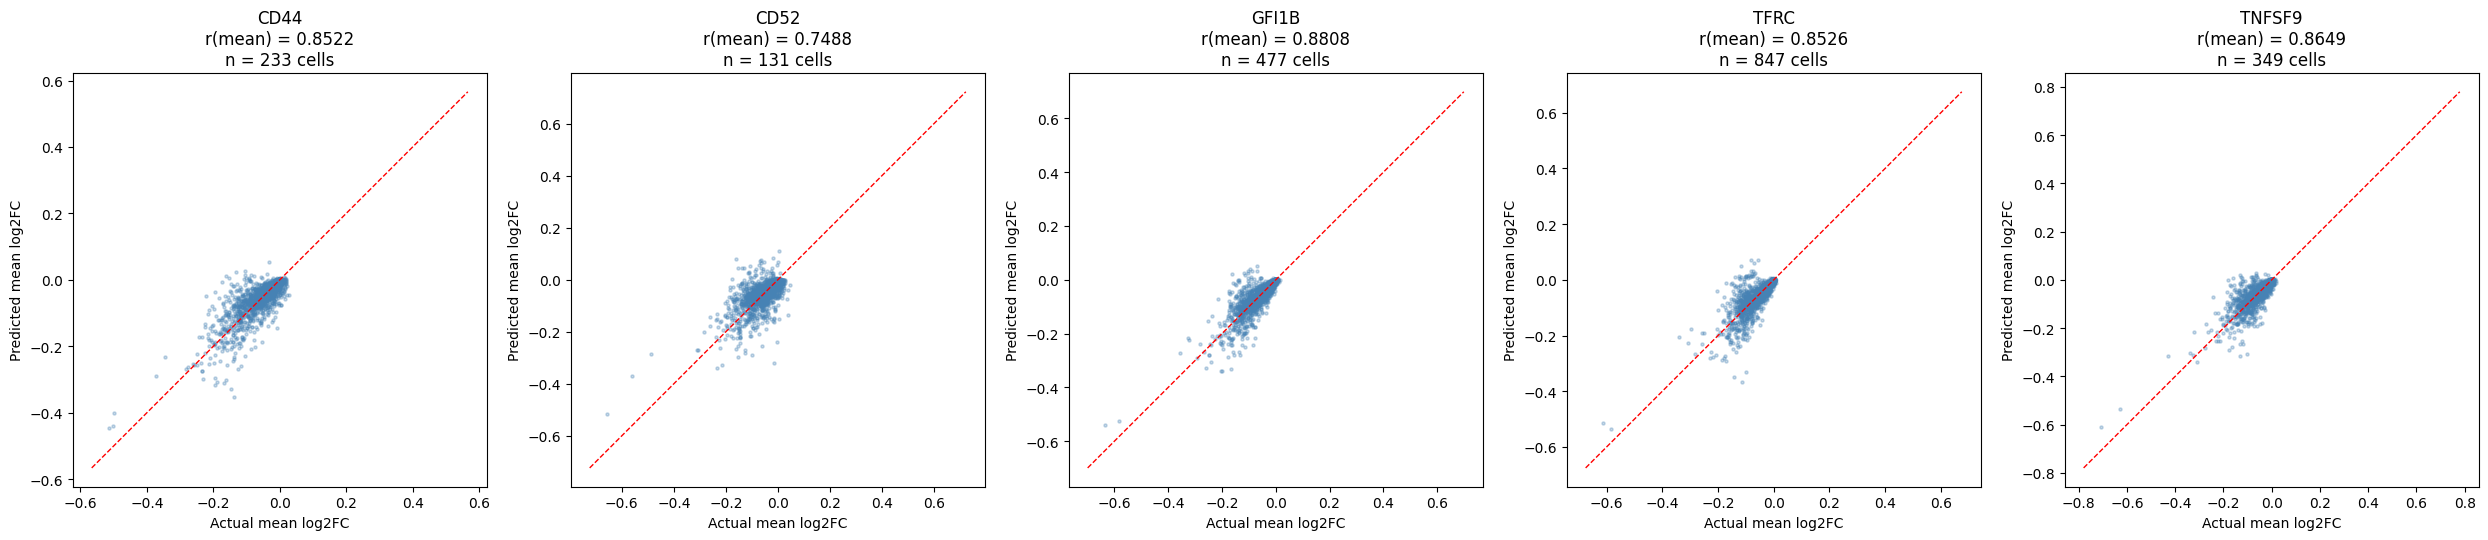

In [ ]:
# Per-gene scatter plots (5 panels)
n_val_genes = len(tss_val_genes)
fig, axes = plt.subplots(1, n_val_genes, figsize=(5 * n_val_genes, 5))
if n_val_genes == 1:
    axes = [axes]

for i, gene in enumerate(tss_val_genes):
    ax = axes[i]
    mask = all_gene_labels == gene

    # Mean across cells for each output gene
    mean_pred = all_preds[mask].mean(axis=0)
    mean_target = all_targets[mask].mean(axis=0)
    r_mean = per_gene_results[gene]['r_mean']

    ax.scatter(mean_target, mean_pred, alpha=0.3, s=5, c='steelblue')
    lim = max(abs(mean_target).max(), abs(mean_pred).max()) * 1.1
    ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1)
    ax.set_xlabel('Actual mean log2FC')
    ax.set_ylabel('Predicted mean log2FC')
    ax.set_title(f'{gene}\nr(mean) = {r_mean:.4f}\nn = {per_gene_results[gene]["n_cells"]} cells')
    ax.set_aspect('equal')

#plt.suptitle('Per-Gene Prediction (Mean Across Cells)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'prediction_per_gene.png', dpi=150, bbox_inches='tight')
plt.savefig(OUTPUT_BASE / 'prediction_per_gene.pdf', bbox_inches='tight')
plt.show()

## 8. Cell-Level Heterogeneity Analysis

Cell-Level Heterogeneity Analysis


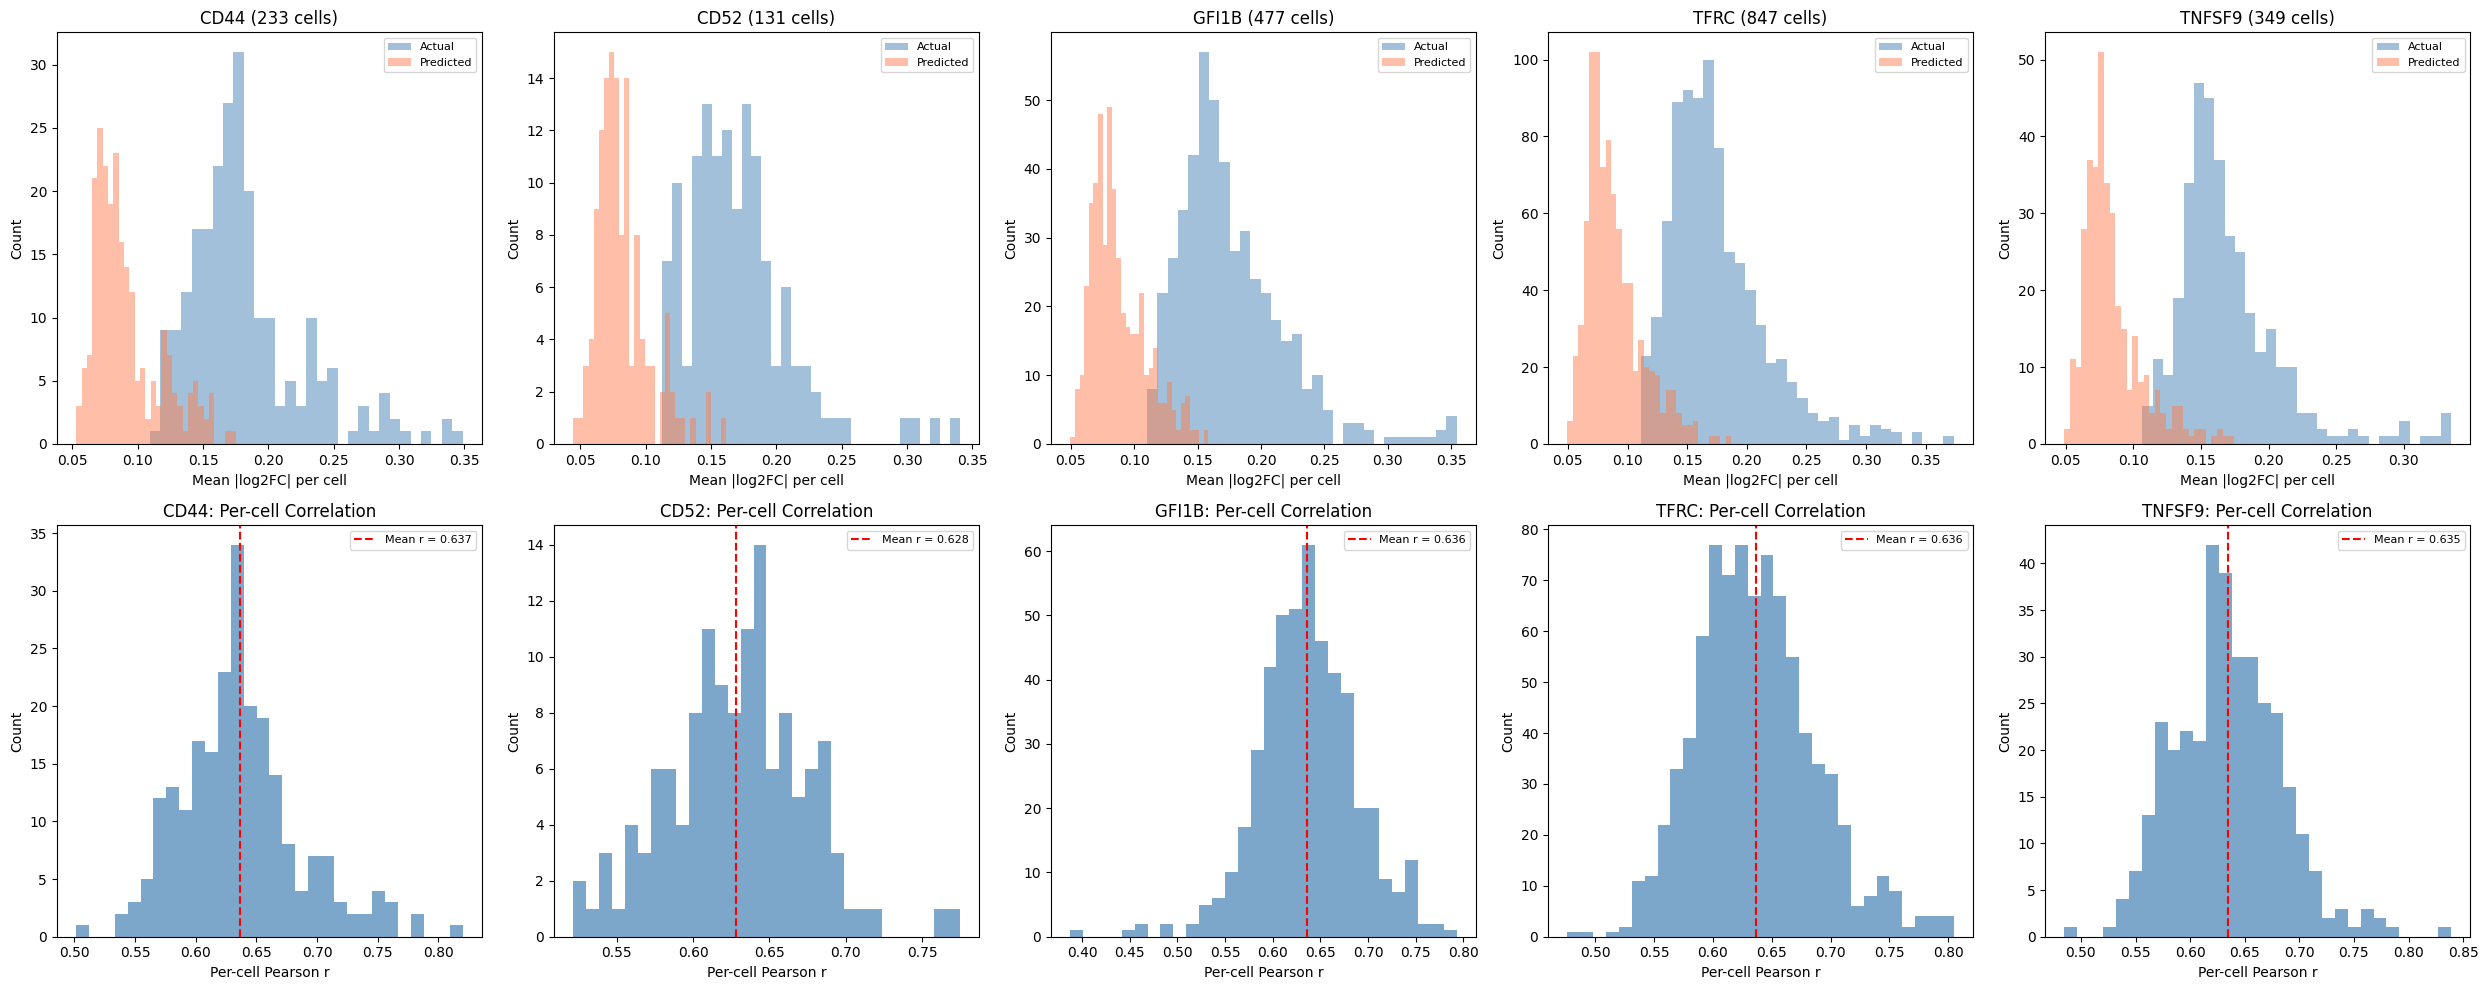

In [ ]:
# Cell-level heterogeneity: within-gene variance
print("Cell-Level Heterogeneity Analysis")
print("=" * 60)

# For each val gene, show the distribution of per-cell predictions
fig, axes = plt.subplots(2, n_val_genes, figsize=(5 * n_val_genes, 10))

for i, gene in enumerate(tss_val_genes):
    mask = all_gene_labels == gene
    gene_preds = all_preds[mask]     # [n_cells, 2360]
    gene_targets = all_targets[mask]  # [n_cells, 2360]

    # Per-cell overall prediction (mean absolute log2FC across genes)
    cell_mean_abs_pred = np.abs(gene_preds).mean(axis=1)
    cell_mean_abs_target = np.abs(gene_targets).mean(axis=1)

    # Top row: distribution of per-cell mean |log2FC|
    ax = axes[0, i]
    ax.hist(cell_mean_abs_target, bins=30, alpha=0.5, label='Actual', color='steelblue')
    ax.hist(cell_mean_abs_pred, bins=30, alpha=0.5, label='Predicted', color='coral')
    ax.set_xlabel('Mean |log2FC| per cell')
    ax.set_ylabel('Count')
    ax.set_title(f'{gene} ({mask.sum()} cells)')
    ax.legend(fontsize=8)

    # Bottom row: per-cell correlation
    ax = axes[1, i]
    cell_correlations = []
    for j in range(gene_preds.shape[0]):
        if np.std(gene_targets[j]) > 0 and np.std(gene_preds[j]) > 0:
            r, _ = pearsonr(gene_preds[j], gene_targets[j])
            cell_correlations.append(r)

    if cell_correlations:
        ax.hist(cell_correlations, bins=30, color='steelblue', alpha=0.7)
        ax.axvline(np.mean(cell_correlations), color='red', linestyle='--',
                   label=f'Mean r = {np.mean(cell_correlations):.3f}')
    ax.set_xlabel('Per-cell Pearson r')
    ax.set_ylabel('Count')
    ax.set_title(f'{gene}: Per-cell Correlation')
    ax.legend(fontsize=8)

#plt.suptitle('Cell-Level Heterogeneity: Per-Cell Prediction Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'cell_heterogeneity.png', dpi=150, bbox_inches='tight')
plt.savefig(OUTPUT_BASE / 'cell_heterogeneity.pdf', bbox_inches='tight')
plt.show()

Focus gene: TFRC (847 cells)


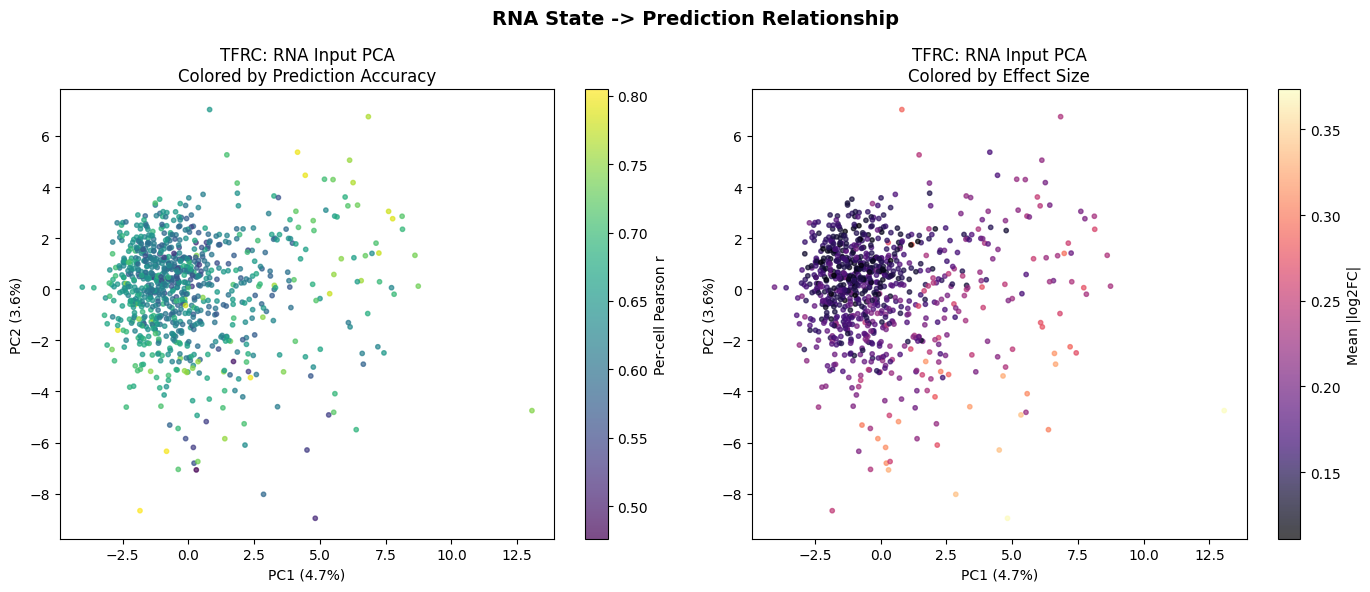


Cells with different RNA states receive different predictions.
PCA variance explained: PC1=4.7%, PC2=3.6%


In [ ]:
# RNA input analysis: PCA of RNA inputs colored by prediction accuracy
from sklearn.decomposition import PCA

# Focus on the gene with most cells for clearest visualization
cell_counts = {gene: (all_gene_labels == gene).sum() for gene in tss_val_genes}
focus_gene = max(cell_counts, key=cell_counts.get)
print(f"Focus gene: {focus_gene} ({cell_counts[focus_gene]} cells)")

mask = all_gene_labels == focus_gene
focus_preds = all_preds[mask]
focus_targets = all_targets[mask]

# Get RNA inputs for these cells
focus_cell_indices = val_cell_indices[mask]
focus_rna = tss_cell_expr[focus_cell_indices]  # [n_cells, 2360]

# Compute per-cell prediction quality (correlation)
cell_quality = []
for j in range(focus_preds.shape[0]):
    if np.std(focus_targets[j]) > 0 and np.std(focus_preds[j]) > 0:
        r, _ = pearsonr(focus_preds[j], focus_targets[j])
        cell_quality.append(r)
    else:
        cell_quality.append(0.0)
cell_quality = np.array(cell_quality)

# PCA of RNA inputs
pca = PCA(n_components=2)
rna_pca = pca.fit_transform(focus_rna)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA colored by prediction correlation
ax = axes[0]
sc = ax.scatter(rna_pca[:, 0], rna_pca[:, 1], c=cell_quality, cmap='viridis',
                s=10, alpha=0.7)
plt.colorbar(sc, ax=ax, label='Per-cell Pearson r')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'{focus_gene}: RNA Input PCA\nColored by Prediction Accuracy')

# PCA colored by mean |log2FC|
ax = axes[1]
cell_effect_size = np.abs(focus_targets).mean(axis=1)
sc = ax.scatter(rna_pca[:, 0], rna_pca[:, 1], c=cell_effect_size, cmap='magma',
                s=10, alpha=0.7)
plt.colorbar(sc, ax=ax, label='Mean |log2FC|')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'{focus_gene}: RNA Input PCA\nColored by Effect Size')

plt.suptitle('RNA State -> Prediction Relationship', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'rna_state_prediction.png', dpi=150, bbox_inches='tight')
plt.savefig(OUTPUT_BASE / 'rna_state_prediction.pdf', bbox_inches='tight')
plt.show()

print(f"\nCells with different RNA states receive different predictions.")
print(f"PCA variance explained: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, PC2={pca.explained_variance_ratio_[1]*100:.1f}%")

## 9. TSS vs SNP Effect Size Comparison

TSS vs SNP Effect Size Comparison
  TSS perturbations: 27
    Mean |log2FC|: 0.1769 +/- 0.0042
  SNP perturbations: 420
    Mean |log2FC|: 0.1895 +/- 0.0266
  TSS/SNP ratio: 0.93x


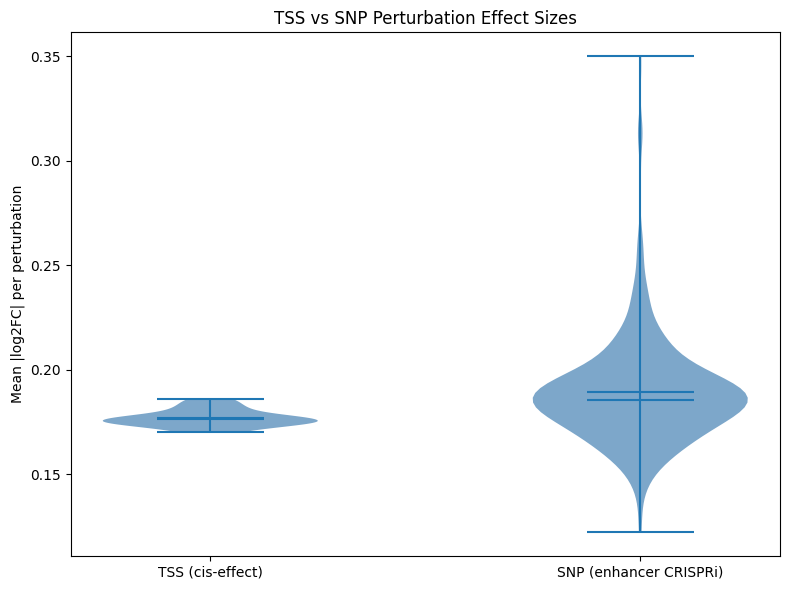

In [ ]:
if HAS_SNP:
    print("TSS vs SNP Effect Size Comparison")
    print("=" * 60)

    # TSS: mean |log2FC| per gene (across cells and output genes)
    tss_mean_effects = []
    for gene_idx_in_target, gene in enumerate(tss_target_gene_names):
        mask = tss_target_gene_idx == gene_idx_in_target
        if mask.sum() > 0:
            tss_mean_effects.append(np.abs(tss_log2fc[mask]).mean())

    # SNP: mean |log2FC| per locus
    snp_mean_effects = []
    for locus_idx in range(len(snp_loci_names)):
        mask = snp_perturbation_idx == locus_idx
        if mask.sum() > 0:
            snp_mean_effects.append(np.abs(snp_log2fc[mask]).mean())

    tss_mean_effects = np.array(tss_mean_effects)
    snp_mean_effects = np.array(snp_mean_effects)

    print(f"  TSS perturbations: {len(tss_mean_effects)}")
    print(f"    Mean |log2FC|: {tss_mean_effects.mean():.4f} +/- {tss_mean_effects.std():.4f}")
    print(f"  SNP perturbations: {len(snp_mean_effects)}")
    print(f"    Mean |log2FC|: {snp_mean_effects.mean():.4f} +/- {snp_mean_effects.std():.4f}")
    print(f"  TSS/SNP ratio: {tss_mean_effects.mean() / snp_mean_effects.mean():.2f}x")

    # Violin plot
    fig, ax = plt.subplots(figsize=(8, 6))
    parts = ax.violinplot([tss_mean_effects, snp_mean_effects],
                          positions=[1, 2], showmeans=True, showmedians=True)
    for pc in parts['bodies']:
        pc.set_facecolor('steelblue')
        pc.set_alpha(0.7)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['TSS (cis-effect)', 'SNP (enhancer CRISPRi)'])
    ax.set_ylabel('Mean |log2FC| per perturbation')
    ax.set_title('TSS vs SNP Perturbation Effect Sizes')
    plt.tight_layout()
    plt.savefig(OUTPUT_BASE / 'tss_vs_snp_effects.png', dpi=150, bbox_inches='tight')
    plt.savefig(OUTPUT_BASE / 'tss_vs_snp_effects.pdf', bbox_inches='tight')
    plt.show()
else:
    print("SNP data not available, skipping comparison.")

In [ ]:
# CDT prediction: does the model also predict TSS > SNP effect sizes?
if HAS_SNP:
    print("CDT prediction of TSS vs SNP effect sizes")

    # Run inference on a sample of SNP cells
    n_snp_sample = min(500, snp_log2fc.shape[0])
    snp_sample_idx = np.random.choice(snp_log2fc.shape[0], n_snp_sample, replace=False)

    snp_preds = []
    snp_batch_size = 16
    with torch.no_grad():
        for start in tqdm(range(0, n_snp_sample, snp_batch_size), desc="SNP inference"):
            end = min(start + snp_batch_size, n_snp_sample)
            batch_idx = snp_sample_idx[start:end]

            dna_batch = []
            for ci in batch_idx:
                locus_idx = snp_perturbation_idx[ci]
                dna_batch.append(snp_enformer_emb[locus_idx])

            dna_tensor = torch.from_numpy(np.stack(dna_batch).astype(np.float32)).to(device)
            rna_tensor = torch.from_numpy(snp_cell_expr[batch_idx].astype(np.float32)).to(device)

            pred = model(dna_tensor, rna_tensor)
            snp_preds.append(pred.cpu().numpy())

    snp_preds = np.concatenate(snp_preds, axis=0)

    # Compare mean |pred| for TSS vs SNP
    tss_pred_effect = np.abs(all_preds).mean()
    snp_pred_effect = np.abs(snp_preds).mean()

    print(f"  Predicted mean |log2FC|:")
    print(f"    TSS: {tss_pred_effect:.4f}")
    print(f"    SNP: {snp_pred_effect:.4f}")
    print(f"    Ratio: {tss_pred_effect / snp_pred_effect:.2f}x")
    print(f"  -> CDT {'correctly' if tss_pred_effect > snp_pred_effect else 'incorrectly'} predicts TSS > SNP effect size")

CDT prediction of TSS vs SNP effect sizes


SNP inference: 100%|██████████| 32/32 [00:14<00:00,  2.21it/s]

  Predicted mean |log2FC|:
    TSS: 0.0876
    SNP: 0.0991
    Ratio: 0.88x
  -> CDT incorrectly predicts TSS > SNP effect size


## 10. Per-Gene Effect Profiles

Per-Gene Trans-Effect Profiles


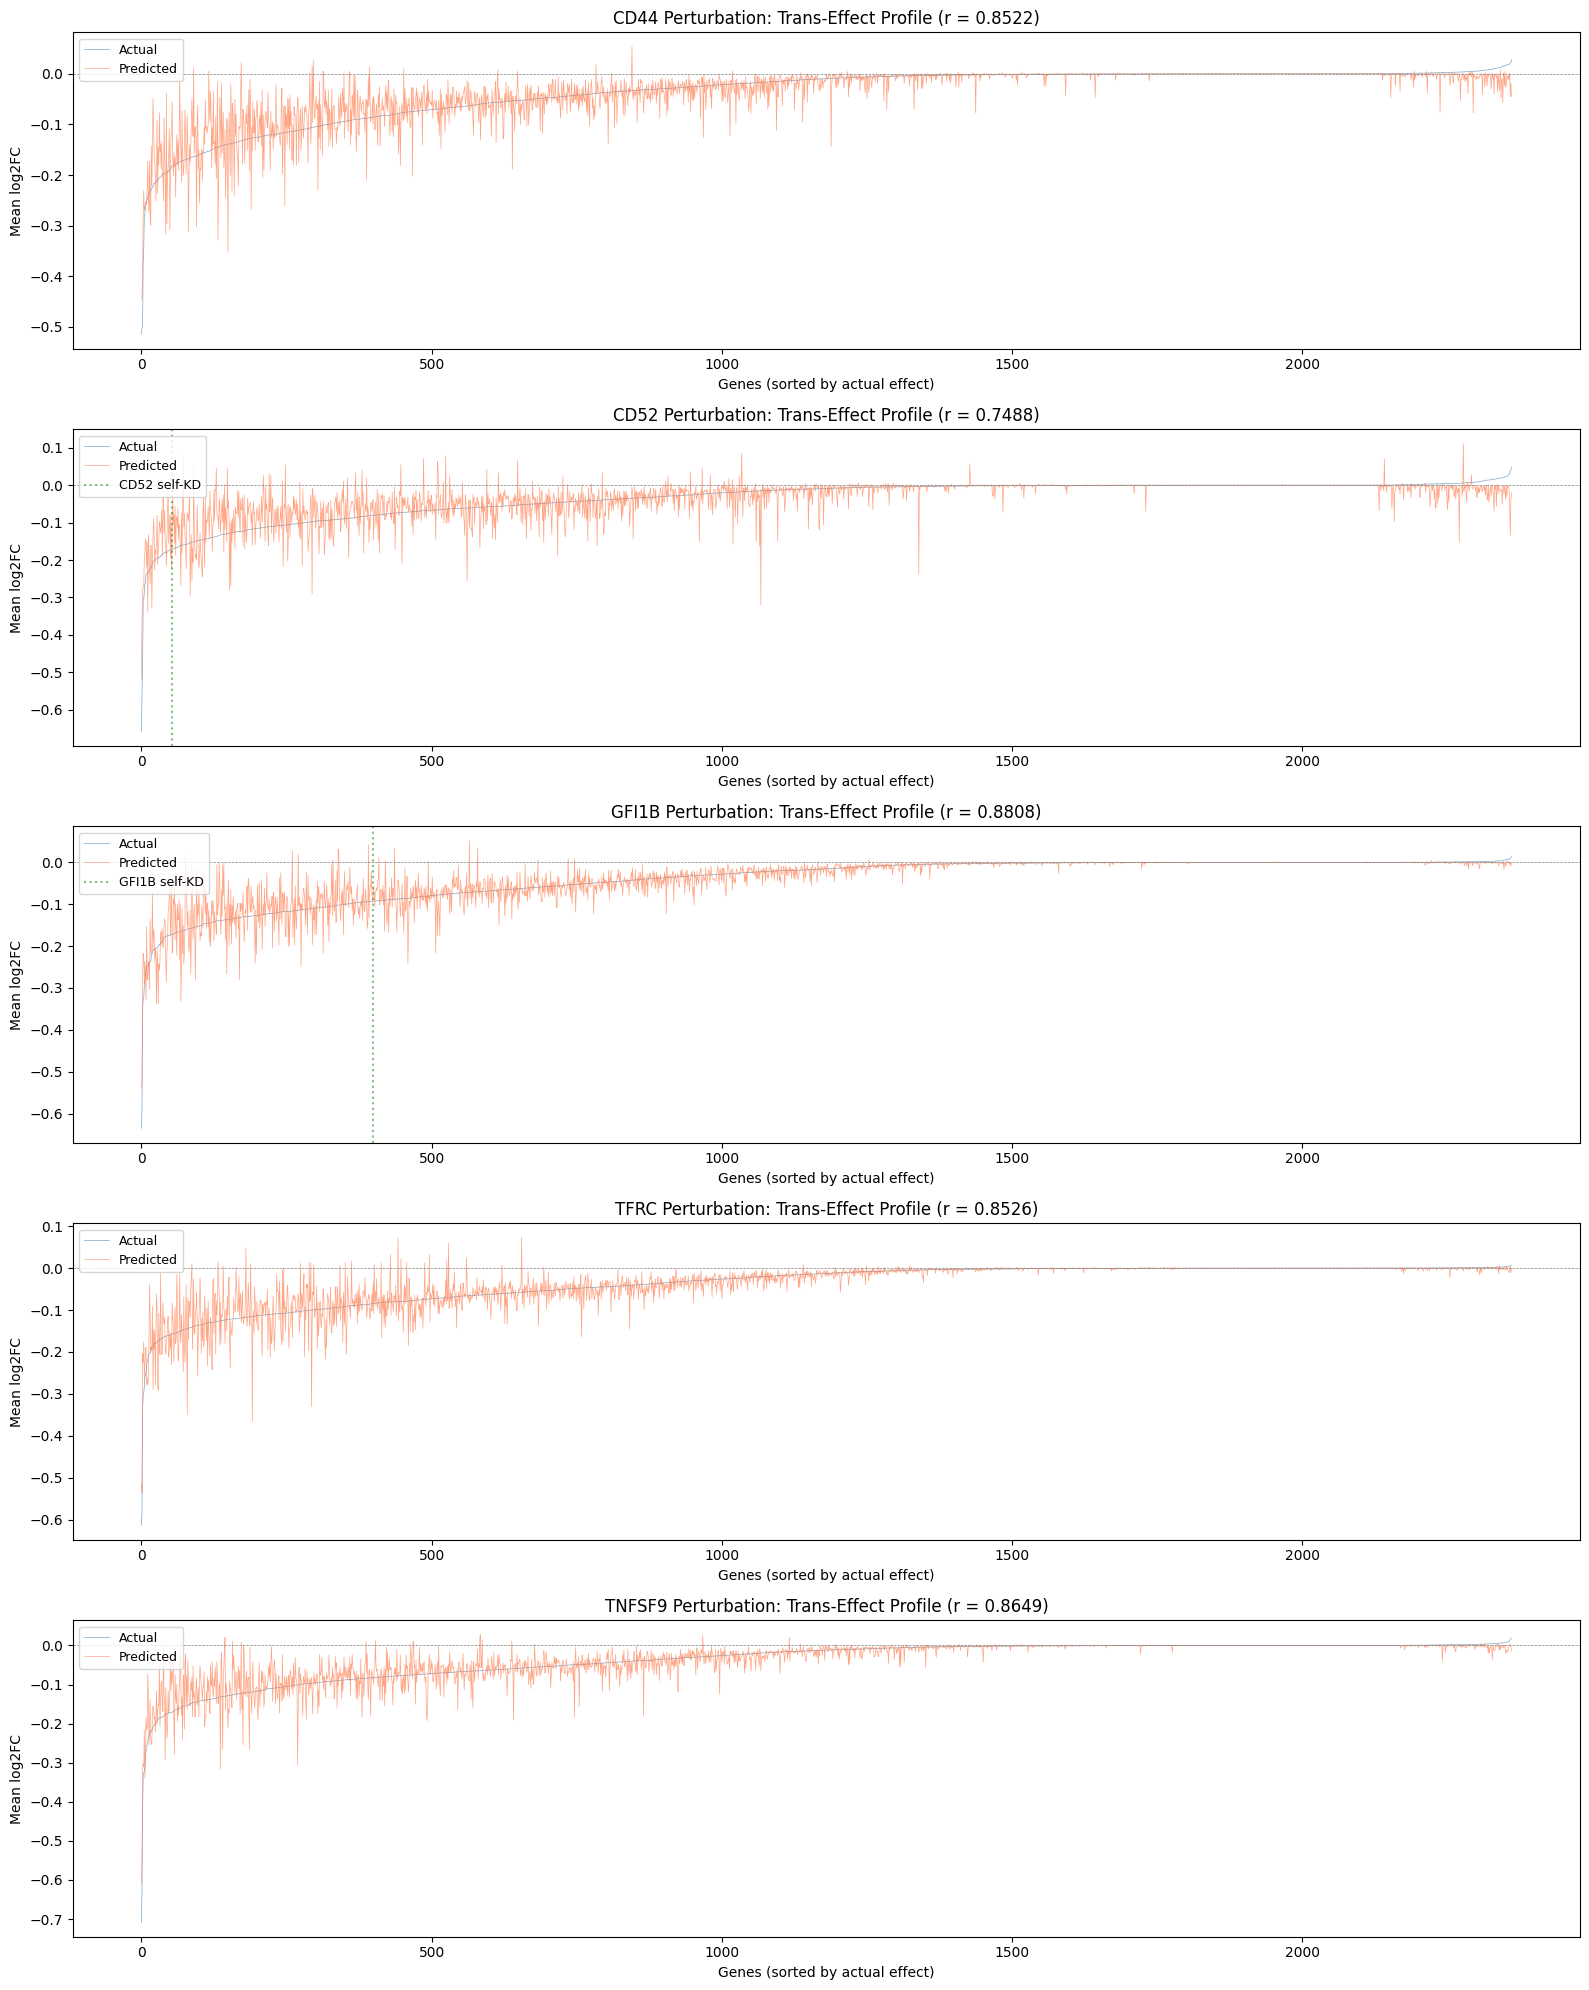

In [ ]:
# Per-gene trans-effect profiles
print("Per-Gene Trans-Effect Profiles")
print("=" * 60)

# For each val gene: plot mean predicted vs actual log2FC across all 2360 genes
fig, axes = plt.subplots(n_val_genes, 1, figsize=(16, 4 * n_val_genes))
if n_val_genes == 1:
    axes = [axes]

for i, gene in enumerate(tss_val_genes):
    ax = axes[i]
    mask = all_gene_labels == gene

    mean_pred = all_preds[mask].mean(axis=0)    # [2360]
    mean_target = all_targets[mask].mean(axis=0)  # [2360]

    # Sort by actual effect for visualization
    sort_idx = np.argsort(mean_target)

    ax.plot(mean_target[sort_idx], alpha=0.7, linewidth=0.5, label='Actual', color='steelblue')
    ax.plot(mean_pred[sort_idx], alpha=0.7, linewidth=0.5, label='Predicted', color='coral')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)

    # Highlight self-knockdown if in CDT list
    if gene in gene_to_idx:
        gene_pos = np.searchsorted(sort_idx, gene_to_idx[gene])
        # Find position of gene_to_idx[gene] in sort_idx
        gene_sorted_pos = np.where(sort_idx == gene_to_idx[gene])[0]
        if len(gene_sorted_pos) > 0:
            ax.axvline(gene_sorted_pos[0], color='green', linestyle=':', alpha=0.5,
                       label=f'{gene} self-KD')

    r_mean = per_gene_results[gene]['r_mean']
    ax.set_xlabel('Genes (sorted by actual effect)')
    ax.set_ylabel('Mean log2FC')
    ax.set_title(f'{gene} Perturbation: Trans-Effect Profile (r = {r_mean:.4f})')
    ax.legend(fontsize=9, loc='upper left')

#plt.suptitle('Trans-Effect Profiles: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'trans_effect_profiles.png', dpi=150, bbox_inches='tight')
plt.savefig(OUTPUT_BASE / 'trans_effect_profiles.pdf', bbox_inches='tight')
plt.show()

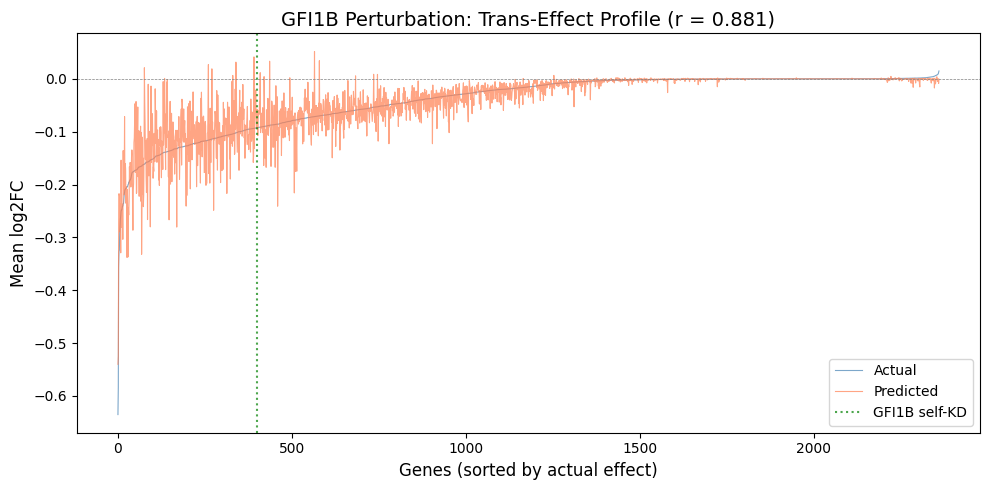

In [ ]:
# GFI1B Trans-Effect Profile (Figure 3C)
fig, ax = plt.subplots(figsize=(10, 5))

gene = 'GFI1B'
mask = all_gene_labels == gene

mean_pred = all_preds[mask].mean(axis=0)
mean_target = all_targets[mask].mean(axis=0)

# Sort by actual effect
sort_idx = np.argsort(mean_target)

ax.plot(mean_target[sort_idx], alpha=0.7, linewidth=0.8, label='Actual', color='steelblue')
ax.plot(mean_pred[sort_idx], alpha=0.7, linewidth=0.8, label='Predicted', color='coral')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)

# Highlight GFI1B self-knockdown
if gene in gene_to_idx:
    gene_sorted_pos = np.where(sort_idx == gene_to_idx[gene])[0]
    if len(gene_sorted_pos) > 0:
        ax.axvline(gene_sorted_pos[0], color='green', linestyle=':', alpha=0.7,
                    label=f'{gene} self-KD')

r_mean = per_gene_results[gene]['r_mean']
ax.set_xlabel('Genes (sorted by actual effect)', fontsize=12)
ax.set_ylabel('Mean log2FC', fontsize=12)
ax.set_title(f'{gene} Perturbation: Trans-Effect Profile (r = {r_mean:.3f})', fontsize=14)
ax.legend(fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'trans_effect_gfi1b.png', dpi=150, bbox_inches='tight')
plt.savefig(OUTPUT_BASE / 'trans_effect_gfi1b.pdf', bbox_inches='tight')
plt.show()

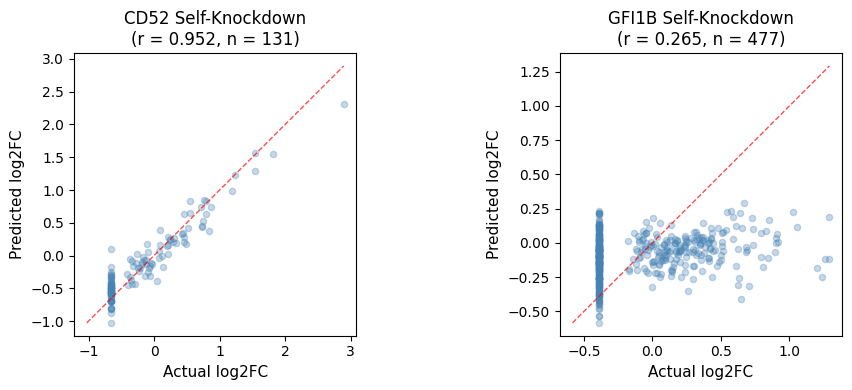

In [ ]:
# Figure 3D: Self-Knockdown Comparison (CD52 vs GFI1B)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

genes_to_compare = ['CD52', 'GFI1B']

for idx, gene in enumerate(genes_to_compare):
    ax = axes[idx]
    mask = all_gene_labels == gene

    # Get self-knockdown values
    gene_idx = gene_to_idx[gene]
    pred_self = all_preds[mask, gene_idx]
    target_self = all_targets[mask, gene_idx]

    # Scatter plot
    ax.scatter(target_self, pred_self, alpha=0.3, s=20, c='steelblue')

    # Diagonal line
    lims = [min(target_self.min(), pred_self.min()),
            max(target_self.max(), pred_self.max())]
    ax.plot(lims, lims, 'r--', alpha=0.7, linewidth=1)

    # Correlation
    r = np.corrcoef(target_self, pred_self)[0, 1]

    ax.set_xlabel('Actual log2FC', fontsize=11)
    ax.set_ylabel('Predicted log2FC', fontsize=11)
    ax.set_title(f'{gene} Self-Knockdown\n(r = {r:.3f}, n = {mask.sum()})', fontsize=12)
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'fig3d_self_knockdown_comparison.png', dpi=150, bbox_inches='tight')
plt.savefig(OUTPUT_BASE / 'fig3d_self_knockdown_comparison.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# GFI1B self-knockdown detailed analysis
gene = 'GFI1B'
mask = all_gene_labels == gene
gene_idx = gene_to_idx[gene]
target_self = all_targets[mask, gene_idx]
pred_self = all_preds[mask, gene_idx]

# Left cluster (x < -0.2) vs right spread (x > 0)
left_mask = target_self < -0.2
right_mask = target_self > 0

print(f"Left cluster (x < -0.2): {left_mask.sum()} cells")
print(f"  Observed range: {target_self[left_mask].min():.3f} ~ {target_self[left_mask].max():.3f}")
print(f"  Unique values: {len(np.unique(target_self[left_mask]))}")

print(f"\nRight spread (x > 0): {right_mask.sum()} cells")
print(f"  Observed range: {target_self[right_mask].min():.3f} ~ {target_self[right_mask].max():.3f}")
print(f"  Unique values: {len(np.unique(target_self[right_mask]))}")

左クラスター (x < -0.2): 267 細胞
  実測値の範囲: -0.392 ~ -0.392
  ユニーク値の数: 1

右の広がり (x > 0): 173 細胞
  実測値の範囲: 0.002 ~ 1.292
  ユニーク値の数: 173


In [ ]:
# GFI1B self-knockdown correlation excluding left cluster (-0.392)
gene = 'GFI1B'
mask = all_gene_labels == gene
gene_idx = gene_to_idx[gene]
target_self = all_targets[mask, gene_idx]
pred_self = all_preds[mask, gene_idx]

# All data
r_all = np.corrcoef(target_self, pred_self)[0, 1]
print(f"All data: r = {r_all:.3f} (n = {len(target_self)})")

# Exclude -0.392
exclude_mask = ~np.isclose(target_self, -0.392)
r_filtered = np.corrcoef(target_self[exclude_mask], pred_self[exclude_mask])[0, 1]
print(f"Excluding -0.392: r = {r_filtered:.3f} (n = {exclude_mask.sum()})")

全データ: r = 0.265 (n = 477)
-0.392除外: r = 0.265 (n = 477)


In [ ]:
# Check exact values
print(f"Left cluster value: {target_self[left_mask][0]:.15f}")

# Exclude by that value
exact_val = target_self[left_mask][0]
exclude_mask = target_self != exact_val
r_filtered = np.corrcoef(target_self[exclude_mask], pred_self[exclude_mask])[0, 1]
print(f"After exclusion: r = {r_filtered:.3f} (n = {exclude_mask.sum()})")

左クラスターの値: -0.391989439725876
除外後: r = 0.162 (n = 210)


In [ ]:
# Check distribution of GFI1B self-knockdown observed values
gene = 'GFI1B'
mask = all_gene_labels == gene
gene_idx = gene_to_idx[gene]
target_self = all_targets[mask, gene_idx]

print(f"Unique values: {len(np.unique(target_self))} / {len(target_self)}")
print(f"Sample values: {target_self[:20]}")

Unique values: 211 / 477
Sample values: [-0.10046357 -0.39198944  0.9043376  -0.39198944  0.06290897 -0.05237207
  0.42630494  0.58493507  0.10083716  0.4429326  -0.07176176 -0.39198944
 -0.39198944 -0.39198944  0.54431313 -0.39198944 -0.39198944 -0.39198944
  0.35841808 -0.39198944]


In [ ]:
# Case study: GFI1B and CD52 trans-targets
print("\nCase Study: Top Trans-Targets")

for gene in ['GFI1B', 'CD52']:
    if gene not in val_gene_set:
        continue

    mask = all_gene_labels == gene
    mean_pred = all_preds[mask].mean(axis=0)
    mean_target = all_targets[mask].mean(axis=0)

    # Top predicted trans-targets (most negative = most down-regulated)
    top_down_pred = np.argsort(mean_pred)[:10]
    top_down_actual = np.argsort(mean_target)[:10]

    print(f"\n{gene} - Top 10 Down-regulated Trans-Targets:")
    print(f"  {'Gene':<12} {'Predicted':>10} {'Actual':>10}")
    print(f"  {'-'*32}")
    for idx in top_down_pred:
        print(f"  {cdt_genes[idx]:<12} {mean_pred[idx]:>10.4f} {mean_target[idx]:>10.4f}")

    # Overlap between predicted and actual top targets
    top_50_pred = set(np.argsort(np.abs(mean_pred))[-50:])
    top_50_actual = set(np.argsort(np.abs(mean_target))[-50:])
    overlap = top_50_pred & top_50_actual
    print(f"\n  Top 50 overlap: {len(overlap)}/50 ({len(overlap)/50*100:.0f}%)")
    if overlap:
        print(f"  Overlap genes: {[cdt_genes[i] for i in sorted(overlap)][:10]}...")


Case Study: Top Trans-Targets

GFI1B - Top 10 Down-regulated Trans-Targets:
  Gene          Predicted     Actual
  --------------------------------
  G0S2            -0.5403    -0.6354
  TXNIP           -0.5247    -0.5840
  ASPM            -0.3380    -0.2047
  MAGOH           -0.3371    -0.2003
  SRSF4           -0.3321    -0.1651
  RSRP1           -0.3293    -0.2575
  MACF1           -0.3037    -0.2409
  RRAGC           -0.2896    -0.2929
  CENPF           -0.2865    -0.1763
  BTG2            -0.2808    -0.2483

  Top 50 overlap: 30/50 (60%)
  Overlap genes: ['HES4', 'UBR4', 'SRSF10', 'RSRP1', 'STMN1', 'ZNF593', 'SH3BGRL3', 'CDCA8', 'RRAGC', 'MACF1']...

CD52 - Top 10 Down-regulated Trans-Targets:
  Gene          Predicted     Actual
  --------------------------------
  TXNIP           -0.5174    -0.6579
  G0S2            -0.3699    -0.5600
  ATP1A1          -0.3397    -0.2337
  CENPF           -0.3269    -0.2135
  OSBPL9          -0.3197    -0.0148
  ARPC5           -0.2961    -0.15

## 11. Summary Statistics & Save

In [ ]:
# Summary
print("=" * 60)
print("PREDICTION ANALYSIS SUMMARY")
print("=" * 60)

print(f"\nOverall Performance:")
print(f"  Pearson r (all cells x all genes) = {overall_r:.4f}")
print(f"  Spearman rho = {overall_rho:.4f}")

print(f"\nPer-Gene Results:")
for gene in tss_val_genes:
    res = per_gene_results[gene]
    print(f"  {gene}: r(all)={res['r_all']:.4f}, r(mean)={res['r_mean']:.4f}, n_cells={res['n_cells']}")

print(f"\nMean r(all): {np.mean([r['r_all'] for r in per_gene_results.values()]):.4f}")
print(f"Mean r(mean): {np.mean([r['r_mean'] for r in per_gene_results.values()]):.4f}")

# Save results
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
results = {
    'timestamp': timestamp,
    'overall_r': float(overall_r),
    'overall_rho': float(overall_rho),
    'per_gene': {gene: res for gene, res in per_gene_results.items()},
    'n_val_cells': int(len(val_cell_indices)),
    'val_genes': tss_val_genes,
}

with open(OUTPUT_BASE / f'prediction_results_{timestamp}.json', 'w') as f:
    json.dump(results, f, indent=2, cls=NumpyEncoder)

print(f"\nResults saved to {OUTPUT_BASE}")
print("Done!")

PREDICTION ANALYSIS SUMMARY

Overall Performance:
  Pearson r (all cells x all genes) = 0.6373
  Spearman rho = 0.4382

Per-Gene Results:
  CD44: r(all)=0.6400, r(mean)=0.8522, n_cells=233
  CD52: r(all)=0.6295, r(mean)=0.7488, n_cells=131
  GFI1B: r(all)=0.6321, r(mean)=0.8808, n_cells=477
  TFRC: r(all)=0.6405, r(mean)=0.8526, n_cells=847
  TNFSF9: r(all)=0.6371, r(mean)=0.8649, n_cells=349

Mean r(all): 0.6358
Mean r(mean): 0.8399

Results saved to /content/drive/MyDrive/cdt_outputs/morris_analysis_stage1_5
Done!
